In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import json
import pandas as pd
from datasets import Dataset
from datasets import load_dataset
import random
import numpy as np

In [ ]:
!pip install transformers==4.28.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.0/110.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 12.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 17.4 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)


# Создание датасета

## Классификационный датасет на русском

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-ru")
model = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-en-ru")

In [ ]:
!wget https://raw.githubusercontent.com/clinc/oos-eval/refs/heads/master/data/data_full.json

In [ ]:
with open('/content/clinc_oos_full.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

In [ ]:
for key in data.keys():
  for item in data[key]:
    if not item["label"]:
      print(item)

In [ ]:
# with open('data_full.json', 'r', encoding='utf-8') as f:
#     data = json.load(f)


new_data = []

for item in data.keys():
  # if item in ['oos_val', 'oos_test', 'oos_train']:
  #   continue
  for i in data[item]:
    # if i[1] in ['account_blocked', 'card_declined', 'damaged_card',
    #                       'freeze_account', 'report_fraud', 'report_lost_card',
    #                       'new_card', 'replacement_card_duration', 'international_visa', 'balance', 'transactions', 'spending_history', 'direct_deposit',
    #                      'transfer', 'pay_bill', 'bill_balance', 'bill_due',
    #                      'min_payment', 'payday', 'credit_limit', 'credit_limit_change', 'credit_score',
    #                        'improve_credit_score', 'interest_rate', 'apr',
    #                        'application_status']:
    # if i:
    new_data.append([i['translation'], i['label']])

In [ ]:
# df = pd.DataFrame(new_data, columns=['text', 'label'])
df = pd.DataFrame(new_data, columns=['text', 'label'])

In [ ]:
df

In [ ]:
# hf_dataset = Dataset.from_pandas(df)
ru_ds = Dataset.from_pandas(df)

In [ ]:
# def translate(text):
#     """
#     Переводит один текст с английского на русский
#     """
#     # Токенизация
#     inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)

#     # Генерация
#     translated = model.generate(
#         **inputs,
#         max_length=512,
#         num_beams=4,  # лучше качество
#         early_stopping=True
#     )

#     # Декодирование
#     return tokenizer.decode(translated[0], skip_special_tokens=True)

In [ ]:
# ru_data = []

# for item in hf_dataset:
#   translation = translate(item['text'])
#   ru_data.append([translation, item['label']])

In [ ]:
# print(ru_data)
# print(len(ru_data))

In [ ]:
# ru_df = pd.DataFrame(ru_data, columns=['text', 'label'])
# ru_ds = Dataset.from_pandas(ru_df)

In [ ]:
# text = "\n".join(["|".join(item) for item in ru_data])
# print(text[:1000])
text = "\n".join(["|".join(item) for item in new_data])
print(text[:1000])

In [ ]:
with open("ru_data_new.txt", "w") as out:
  out.write(text)

In [ ]:
# print([item for item in ru_ds])

## Шумный датасет на русском


In [ ]:
# with open("ru_data_new.txt") as readable:
#   dataraw = readable.read()
# ru_data = [list(item.split("|")) for item in dataraw.split("\n")]

In [ ]:
from datasets import load_dataset

noise = load_dataset("Den4ikAI/russian_dialogues")

In [ ]:
noise['train'][0]

In [ ]:
len(noise['train'])

In [ ]:
noise_frases = []
counter = 0
for item in noise['train']:
  if item['question'] is not None:
    if len(item['question'].split()) < 9:
      noise_frases.append(item['question'])
      counter+=1
    if item['answer'] is not None:
      if len(item['answer'].split()) < 9:
        noise_frases.append(item['answer'])
  if counter == 100000:
    break
del(noise)

In [ ]:
random.shuffle(noise_frases)
len(noise_frases)

In [ ]:
from collections import defaultdict
shortnoise = []
lengths = defaultdict(list)
for item in noise_frases:
  lengths[len(item.split())].append(item)
  if len(item.split()) in range(0, 3):
    shortnoise.append(item)

In [ ]:
print(len(shortnoise))

In [ ]:
from typing import Sequence, TypeVar, List

T = TypeVar("T")

def insert_many_random(lst: Sequence[T], inserts: Sequence[T], seed: int | None = None) -> List[T]:
    rnd = random.Random(seed)
    n = len(lst)
    k = len(inserts)

    positions = sorted(rnd.sample(range(n + 1), k))

    out: List[T] = []
    last = 0
    newlabel = []
    for pos, ins in zip(positions, inserts):
        new_ins = ins.split()
        out.extend(lst[last:pos])
        newlabel.extend(["0"]*(pos-last)+["N"]*len(new_ins))
        out.extend(new_ins)
        last = pos
    newlabel += ["0"]*(n-last)
    out.extend(lst[last:])
    return " ".join(out), newlabel

print(insert_many_random(["1", "2", "3", "4", "5"], ["A", "B", "C"], seed=42))

In [ ]:
choices = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
p1 = np.array([0.2, 0.1, 0.1, 0.15, 0.15, 0.15, 0.05, 0.05, 0.05])
number = np.random.choice(choices, size=1, p=p1)[0]
number

In [ ]:
new_data[0]

In [ ]:
seed = 1337
noise_data = []
for item in new_data:
  oldword = "".join(ch.lower() for ch in item[0] if ch.isalpha() or ch == " ").split()
  needed = []
  numbers = np.array([0, 1, 2, 3, 4])
  p = np.array([0.2, 0.25, 0.25, 0.15, 0.15])
  number = 100
  while number > len(oldword):
    number = np.random.choice(numbers, size=1, p=p)[0]
  choices = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
  p1 = np.array([0.2, 0.1, 0.1, 0.15, 0.15, 0.15, 0.05, 0.05, 0.05])
  length = 10
  while not lengths[length]:
    length = np.random.choice(choices, size=1, p=p1)[0]
  if number != 0:
    for i in range(number):
      newsmth = None
      while newsmth is None:
        newsmth = "".join(ch.lower() for ch in lengths[length].pop() if ch.isalpha() or ch == " ")
      needed.append(newsmth)
    words, label = insert_many_random(oldword, needed, seed=seed)
    noise_data.append([words.split(), label, item[1]])
  else:
    noise_data.append([oldword, ["0"]*len(oldword), item[1]])

In [ ]:
noise_df = pd.DataFrame(noise_data, columns=['text', 'label', 'oldlabel'])

In [ ]:
for item in noise_data:
  if len(item[0]) != len(item[1]):
    print(item[0])
    print(item[1])
    print("\n\n\n")

In [ ]:
counter = 0
for item in noise_data:
  if "N" not in item[1]:
    counter+=1
counter

In [ ]:

for noizzy, original in zip(noise_data, new_data):
  oldtext = "".join([ch.lower() for ch in original[0] if ch.isalpha() or ch == " "])
  oldtext = oldtext.split()
  newtext = [word for word, label in zip(noizzy[0], noizzy[1]) if label == "0"]
  if oldtext != newtext:
    print(oldtext)
    print(newtext)

In [ ]:
noise_df

In [ ]:
noise_ds = Dataset.from_pandas(noise_df)
print(noise_ds, "\n", noise_ds[23699])

In [ ]:
bigarray = []
for item in noise_data:
  bigarray.append("|".join([" ".join(item[0]), " ".join(item[1]), item[2]]))
text = "\n".join(bigarray)
print(text[:1000])

In [ ]:
with open("noise_data_new.txt", "w") as out:
  out.write(text)

In [ ]:
amounts = []
for item in noise_data:
  counter = 0
  for ch in item[1]:
    if ch == "N":
      counter+=1
  amounts.append(counter)

In [ ]:
statistics = defaultdict(int)
for item in amounts:
  statistics[item]+=1
# print("\n".join([f"{k}: {v}" for k, v in statistics.items()]))
print(f"0: {statistics[0]}")
print(f"1-4: {statistics[1]+statistics[2]+statistics[3]+statistics[4]}")
print(f"5-8: {statistics[5]+statistics[6]+statistics[7]+statistics[8]}")
print(f"9-12: {statistics[9]+statistics[10]+statistics[11]+statistics[12]}")
print(f"13-16: {statistics[13]+statistics[14]+statistics[15]+statistics[16]}")
print(sum(amounts)/len(amounts))

In [ ]:
posstatistics = defaultdict(int)
for item in noise_data:
  for i in range(len(item[1])):
    if item[1][i] == "N":
      if i==len(item):
        posstatistics[-1]+=1
      else:
        posstatistics[i]+=1
print("\n".join([f"{k}: {v}" for k, v in posstatistics.items()]))

In [ ]:
with open('noise_data.json', 'w', encoding='utf-8') as f:
    json.dump(noise_ds.to_list(), f, ensure_ascii=False, indent=2)

## Выделение подклассов в датасете

In [ ]:
with open('/content/our_noise_data_full.json', 'r', encoding='utf-8') as f:
    noise_data_full = json.load(f)

In [ ]:
banking_labels = ['transfer', 'transactions', 'balance', 'freeze_account', 'pay_bill', 'bill_balance', 'bill_due', 'interest_rate', 'routing_number', 'minimum_payment', 'order_checks', 'pin_change', 'report_fraud', 'account_blocked', 'spending_history']
credit_cards_labels = ['credit_score', 'report_lost_card', 'credit_limit', 'rewards_balance', 'new_card', 'application_status', 'card_declined', 'international_fees', 'apr', 'redeem_rewards', 'credit_limit_change', 'damaged_card', 'replacement_card_duration', 'improve_credit_score', 'expiration_date']
travel_labels = ['book_flight', 'book_hotel', 'car_rental', 'travel_suggestion', 'travel_alert', 'travel_notification', 'carry_on', 'timezone', 'vaccines', 'flight_status', 'international_visa', 'lost_luggage', 'plug_type', 'exchange_rate']
work_labels = ['direct_deposit', 'pto_request', 'taxes', 'payday', 'pto_balance', 'pto_request_status', 'next_holiday', 'insurance', 'insurance_change', 'schedule_meeting', 'pto_used', 'meeting_schedule', 'income']
all_labels = ['transfer', 'transactions', 'balance', 'freeze_account', 'pay_bill', 'bill_balance', 'bill_due', 'interest_rate', 'routing_number', 'minimum_payment', 'order_checks', 'pin_change', 'report_fraud', 'account_blocked', 'spending_history', 'credit_score', 'report_lost_card', 'credit_limit', 'rewards_balance', 'new_card', 'application_status', 'card_declined', 'international_fees', 'apr', 'redeem_rewards', 'credit_limit_change', 'damaged_card', 'replacement_card_duration', 'improve_credit_score', 'expiration_date', 'recipe', 'restaurant_reviews', 'calories', 'nutrition_info', 'restaurant_suggestion', 'ingredients_list', 'ingredient_substitution', 'cook_time', 'food_last', 'meal_suggestion', 'restaurant_reservation', 'confirm_reservation', 'how_busy', 'cancel_reservation', 'accept_reservations', 'shopping_list', 'shopping_list_update', 'next_song', 'play_music', 'update_playlist', 'todo_list', 'todo_list_update', 'calendar', 'calendar_update', 'what_song', 'order', 'order_status', 'reminder', 'reminder_update', 'smart_home', 'traffic', 'directions', 'gas', 'gas_type', 'distance', 'current_location', 'mpg', 'oil_change_when', 'oil_change_how', 'jump_start', 'uber', 'schedule_maintenance', 'last_maintenance', 'tire_pressure', 'tire_change', 'book_flight', 'book_hotel', 'car_rental', 'travel_suggestion', 'travel_alert', 'travel_notification', 'carry_on', 'timezone', 'vaccines', 'translate', 'flight_status', 'international_visa', 'lost_luggage', 'plug_type', 'exchange_rate', 'time', 'alarm', 'share_location', 'find_phone', 'weather', 'text', 'spelling', 'make_call', 'timer', 'date', 'calculator', 'measurement_conversion', 'flip_coin', 'roll_dice', 'definition', 'direct_deposit', 'pto_request', 'taxes', 'payday', 'w2', 'pto_balance', 'pto_request_status', 'next_holiday', 'insurance', 'insurance_change', 'schedule_meeting', 'pto_used', 'meeting_schedule', 'rollover_401k', 'income', 'greeting', 'goodbye', 'tell_joke', 'where_are_you_from', 'how_old_are_you', 'what_is_your_name', 'who_made_you', 'thank_you', 'what_can_i_ask_you', 'what_are_your_hobbies', 'do_you_have_pets', 'are_you_a_bot', 'meaning_of_life', 'who_do_you_work_for', 'fun_fact', 'change_ai_name', 'change_user_name', 'cancel', 'user_name', 'reset_settings', 'whisper_mode', 'repeat', 'no', 'yes', 'maybe', 'change_language', 'change_accent', 'change_volume', 'change_speed', 'sync_device', 'out_of_scope']

In [ ]:
banking_noise_dataset = [item for item in noise_data_full if item.get('oldlabel') in banking_labels]
credit_cards_noise_dataset = [item for item in noise_data_full if item.get('oldlabel') in credit_cards_labels]
travel_noise_dataset = [item for item in noise_data_full if item.get('oldlabel') in travel_labels]
work_noise_dataset = [item for item in noise_data_full if item.get('oldlabel') in work_labels]

In [ ]:
banking_credit_noise_dataset = banking_noise_dataset + credit_cards_noise_dataset
random.shuffle(banking_credit_noise_dataset)

In [ ]:
bctw_noise_dataset = banking_noise_dataset + credit_cards_noise_dataset + travel_noise_dataset + work_noise_dataset
random.shuffle(bctw_noise_dataset)

# Обучение denoise-моделей

## Функции и классы

In [ ]:
def make_last_subtoken_mask(mask, has_cls=True, has_eos=True):
    if has_cls:
        mask = mask[1:]
    if has_eos:
        mask = mask[:-1]
    is_last_word = list((first != second) for first, second in zip(mask[:-1], mask[1:])) + [True]
    if has_cls:
        is_last_word = [False] + is_last_word
    if has_eos:
        is_last_word.append(False)
    return is_last_word

In [ ]:
from collections import Counter
import numpy as np
from torch.utils.data.dataset import Dataset

class DenoiseDataset(Dataset):

    def __init__(self, data, tokenizer, min_count=3, tags=None):
        if 'label' in data.column_names:
            data = data.rename_column('label', 'labels')
        if 'oldlabel' in data.column_names:
            data = data.remove_columns('oldlabel')
        self.data = data
        self.tokenizer = tokenizer
        self.tags_ = ['0', 'N']
        self.tag_indexes_ = {tag: i for i, tag in enumerate(self.tags_)}
        self.ignore_index = -100

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        item = self.data[index]
        tokenization = self.tokenizer(item["text"], is_split_into_words=True)
        last_subtoken_mask = make_last_subtoken_mask(tokenization.word_ids())
        answer = {"input_ids": tokenization["input_ids"], "mask": last_subtoken_mask}
        if "labels" in item:
            labels = [self.tag_indexes_.get(tag) for tag in item["labels"]]
            zero_labels = np.array([self.ignore_index] * len(tokenization["input_ids"]), dtype=int)
            zero_labels[last_subtoken_mask] = labels
            answer["labels"] = zero_labels

        return answer

In [ ]:
import scipy

def predict_with_trainer(trainer, dataset, classes):
    predictions = trainer.predict(dataset)
    answer = []
    for elem, curr_predictions in zip(dataset, predictions.predictions):
        mask = elem["mask"]
        probs = scipy.special.softmax(curr_predictions, axis=-1)[:len(mask)]
        best_indexes = np.argmax(probs, axis=-1)[elem["mask"]]
        best_labels = np.take(classes, best_indexes)
        best_probs = np.max(probs, axis=-1)[elem["mask"]]
        curr_answer = {"labels": best_labels, "probs": best_probs}
        answer.append(curr_answer)
    return answer

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def plot_training_curves(trainer):

    train_losses = []
    eval_losses = []
    lrs = []
    steps = []

    for log in trainer.state.log_history:
        if 'loss' in log and 'eval_loss' not in log:
            train_losses.append(log['loss'])
            steps.append(log.get('step', len(train_losses)))

        if 'eval_loss' in log:
            eval_losses.append(log['eval_loss'])

        if 'learning_rate' in log:
            lrs.append(log['learning_rate'])

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(steps[:len(train_losses)], train_losses, 'b-', linewidth=2, label='Train Loss')
    axes[0].set_xlabel('Steps')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    if eval_losses:
        eval_steps = [log['step'] for log in trainer.state.log_history if 'eval_loss' in log]
        axes[1].plot(eval_steps, eval_losses, 'r-', linewidth=2, label='Eval Loss')
        axes[1].set_xlabel('Steps')
        axes[1].set_ylabel('Loss')
        axes[1].set_title('Evaluation Loss')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

    axes[2].plot(steps[:len(lrs)], lrs, 'g-', linewidth=2)
    axes[2].set_xlabel('Steps')
    axes[2].set_ylabel('Learning Rate')
    axes[2].set_title('Learning Rate Schedule')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## FacebookAI/xlm-roberta-base

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, AutoModelForTokenClassification

tokenizer = AutoTokenizer.from_pretrained("FacebookAI/xlm-roberta-base")
model = AutoModelForTokenClassification.from_pretrained("FacebookAI/xlm-roberta-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Преобразование датасетов

In [ ]:
from datasets import Dataset
hf_dataset = Dataset.from_list(bctw_noise_dataset)

split_bctw_noise_dataset = hf_dataset.train_test_split(test_size=0.2, seed=42)

train_bctw_noise_dataset = DenoiseDataset(data=split_bctw_noise_dataset["train"], tokenizer=tokenizer)
test_bctw_noise_dataset = DenoiseDataset(data=split_bctw_noise_dataset["test"], tokenizer=tokenizer)

print(split_bctw_noise_dataset["train"][2])
print(train_bctw_noise_dataset[2])

{'text': ['сколько', 'у', 'меня', 'осталось', 'ничего', 'дней', 'отпуска'], 'label': ['0', '0', '0', '0', 'N', '0', '0'], 'oldlabel': 'pto_balance'}
{'input_ids': [0, 47381, 84, 3925, 152974, 13987, 27091, 142115, 2], 'mask': [False, True, True, True, True, True, True, True, False], 'labels': array([-100,    0,    0,    0,    0,    1,    0,    0, -100])}


In [ ]:
from datasets import Dataset
hf_dataset = Dataset.from_json('noise_data_full.json')

split_full_noise_dataset = hf_dataset.train_test_split(test_size=0.2, seed=42)


train_full_noise_dataset = DenoiseDataset(data=split_full_noise_dataset["train"], tokenizer=tokenizer)
test_full_noise_dataset = DenoiseDataset(data=split_full_noise_dataset["test"], tokenizer=tokenizer)

print(split_full_noise_dataset["train"][2])
print(train_full_noise_dataset[2])

Generating train split: 0 examples [00:00, ? examples/s]

{'text': ['вы', 'можете', 'создать', 'для', 'меня', 'почему', 'мальчикам', 'не', 'нравятса', 'девочки', 'панки', 'запрос', 'на', 'отпуск', 'исполнить', 'тогда', 'возможно', 'больше', 'не', 'захочешь', 'с', 'от', 'ее', 'значимости', 'в', 'мироощущении', 'мужчины', 'марта', 'по', 'апреля'], 'label': ['0', '0', '0', '0', '0', 'N', 'N', 'N', 'N', 'N', 'N', '0', '0', '0', 'N', 'N', 'N', 'N', 'N', 'N', '0', 'N', 'N', 'N', 'N', 'N', 'N', '0', '0', '0'], 'oldlabel': 'pto_request'}
{'input_ids': [0, 811, 5026, 88210, 518, 3925, 24651, 111508, 1258, 77, 21717, 13510, 1343, 2257, 29513, 44650, 753, 21665, 69765, 29, 134354, 90216, 1117, 20878, 23334, 7329, 77, 15257, 12963, 19876, 135, 183, 4641, 6, 176044, 2509, 49, 105539, 197, 24898, 141313, 89, 138165, 35185, 129, 72142, 2], 'mask': [False, True, True, True, True, True, True, False, True, True, False, False, False, True, False, True, False, True, True, True, True, False, True, True, True, True, True, False, False, True, True, True, True, Fals

In [ ]:
from datasets import Dataset
hf_dataset = Dataset.from_list(banking_credit_noise_dataset)

split_banking_credit_noise_dataset = hf_dataset.train_test_split(test_size=0.2, seed=42)

train_banking_credit_noise_dataset = DenoiseDataset(data=split_banking_credit_noise_dataset["train"], tokenizer=tokenizer)
test_banking_credit_noise_dataset = DenoiseDataset(data=split_banking_credit_noise_dataset["test"], tokenizer=tokenizer)

print(split_banking_credit_noise_dataset["train"][2])
print(train_banking_credit_noise_dataset[2])

{'text': ['отправить', 'более', 'между', 'моими', 'совместными', 'и', 'несовместимыми', 'счетами'], 'label': ['0', '0', '0', '0', '0', '0', '0', '0'], 'oldlabel': 'transfer'}
{'input_ids': [0, 66815, 1117, 5138, 5842, 163800, 89, 190439, 23453, 35, 77, 38920, 68733, 130, 23453, 25862, 1281, 2], 'mask': [False, False, True, True, True, False, True, False, True, True, False, False, False, False, True, False, True, False], 'labels': array([-100, -100,    0,    0,    0, -100,    0, -100,    0,    0, -100,
       -100, -100, -100,    0, -100,    0, -100])}


In [ ]:
import torch

test = [
  {
    "text": "переведите деньги на мой счет".split(),
    "labels": ['0','0','0','0','0']
  },
  {
    "text": "алиса какой канал переведите сто долларов на сберкнижку".split(),
    "labels": ['N','N','N','0','0','0','0','0']
  },
  {
    "text": "выключи телевизор заблокируй карту срочно пожалуйста".split(),
    "labels": ['N','N','0','0','0','0']
  },
  {
    "text": "привет как дела что делаешь переведи пять тысяч на вклад".split(),
    "labels": ['N','N','N','N','N','0','0','0','0','0']
  },
  {
    "text": "ну я ему говорю а он такой слушай переведите пожалуйста средства".split(),
    "labels": ['N','N','N','N','N','N','N','N','0','0','0']
  },
  {
    "text": "какой баланс моей карты".split(),
    "labels": ['0','0','0','0']
  },
  {
    "text": "погода сегодня алиса какой баланс на карте".split(),
    "labels": ['N','N','N','0','0','0','0']
  },
  {
    "text": "переведи деньги срочно сделай тише я сказал".split(),
    "labels": ['0','0','0','N','N','N','N']
  },
  {
    "text": "перевод средств на карту сбербанка".split(),
    "labels": ['0','0','0','0','0']
  },
  {
    "text": "иди сюда быстрее посмотри что я нашел переведи сто баксов".split(),
    "labels": ['N','N','N','N','N', 'N', 'N', '0', '0', '0']
  }
]

### banking+credit_cards

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoModelForTokenClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer, DataCollatorForTokenClassification
# from transformers.optimization import AdamW
from torch.optim import AdamW, Adam

import numpy as np


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    pred_labels = np.argmax(logits, axis=-1)
    correct, total, seq_correct = 0, 0, 0

    tp, fp, fn = 0, 0, 0

    for i, (pred_sent_labels, sent_labels) in enumerate(zip(pred_labels, labels)):
        is_correct = True
        for pred_label, label in zip(pred_sent_labels, sent_labels):
            if label != -100:
                if pred_label == label:
                    correct += 1
                    if label == 1:
                        tp += 1
                else:
                    is_correct = False
                    if label == 1:
                        fn += 1
                    if pred_label == 1:
                        fp += 1
                total += 1
        seq_correct += int(is_correct)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {
        "Accuracy": 100 * correct / total,
        "Sentence accuracy": 100 * seq_correct / len(labels),
        "Precision": 100 * precision,
        "Recall": 100 * recall,
        "F1": 100 * f1
    }

banking_credit_denoise_model = AutoModelForTokenClassification.from_pretrained("FacebookAI/xlm-roberta-base", num_labels=len(train_banking_credit_noise_dataset.tags_))
optimizer = AdamW(banking_credit_denoise_model.parameters(), lr=1e-5, weight_decay=0.01)
training_args = TrainingArguments(
                  output_dir="trainer_logs", eval_strategy="steps", save_strategy='steps',
                  logging_strategy="steps", save_total_limit=2,
                  num_train_epochs=4, eval_steps=100, disable_tqdm=False,
                  metric_for_best_model='Accuracy',
                  warmup_ratio=0.1,
                  report_to="none"
              )
banking_credit_denoise_trainer = Trainer(
    model=banking_credit_denoise_model,
    optimizers=(optimizer, None),
    args=training_args,
    data_collator=DataCollatorForTokenClassification(tokenizer=tokenizer),
    train_dataset=train_banking_credit_noise_dataset,
    eval_dataset=test_banking_credit_noise_dataset,
    compute_metrics=compute_metrics)
banking_credit_denoise_trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,Sentence accuracy,Precision,Recall,F1
100,No log,0.376098,83.990365,27.857143,83.154122,81.489287,82.313287
200,No log,0.169859,93.721397,56.309524,92.698192,93.642431,93.167919
300,No log,0.130198,95.222802,65.238095,94.239112,95.381103,94.806668
400,No log,0.110993,96.146126,70.238095,95.481507,96.118721,95.799055
500,0.264958,0.119541,96.033721,71.428571,96.345811,94.924482,95.629866
600,0.264958,0.100829,96.836612,74.285714,96.231682,96.873902,96.551724
700,0.264958,0.105987,96.732236,74.880952,96.239286,96.628030,96.433266
800,0.264958,0.097381,97.125652,76.428571,96.627053,97.102213,96.864050
900,0.264958,0.103681,96.965074,75.476190,97.110954,96.224096,96.665490
1000,0.080015,0.107406,96.852670,76.309524,97.491938,95.574289,96.523590


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1680, training_loss=0.12234325181870233, metrics={'train_runtime': 589.1402, 'train_samples_per_second': 22.813, 'train_steps_per_second': 2.852, 'total_flos': 291786822037632.0, 'train_loss': 0.12234325181870233, 'epoch': 4.0})

In [ ]:
test_results = banking_credit_denoise_trainer.evaluate(test_banking_credit_noise_dataset)
test_results

{'eval_loss': 0.10365194827318192,
 'eval_Accuracy': 97.37454837414693,
 'eval_Sentence accuracy': 78.92857142857143,
 'eval_Precision': 97.36981465136805,
 'eval_Recall': 96.87390235335441,
 'eval_F1': 97.12122545998768,
 'eval_runtime': 2.5516,
 'eval_samples_per_second': 329.203,
 'eval_steps_per_second': 41.15,
 'epoch': 4.0}

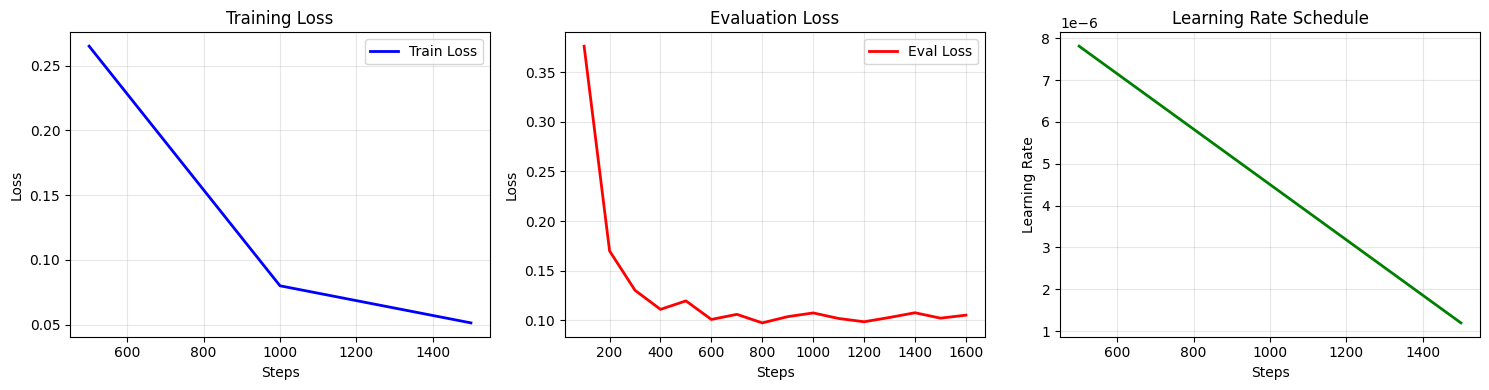

In [ ]:
plot_training_curves(banking_credit_denoise_trainer)

In [ ]:
testing = DenoiseDataset(data=Dataset.from_list(test), tokenizer=tokenizer)
predictions = predict_with_trainer(banking_credit_denoise_trainer, testing, classes=train_banking_credit_noise_dataset.tags_)
for word, label in zip(test, predictions):
      print(" ".join(word['text']) + '\n' + " ".join(label['labels']) + '\n' + " ".join(word['labels']))
      print(f"{sum([1 if i==k else 0 for i, k in zip(label['labels'], word['labels'])])}/{len(word['labels'])}")
print()

переведите деньги на мой счет
0 0 0 0 0
0 0 0 0 0
5/5
алиса какой канал переведите сто долларов на сберкнижку
0 N N 0 0 0 0 0
N N N 0 0 0 0 0
7/8
выключи телевизор заблокируй карту срочно пожалуйста
0 0 0 0 0 0
N N 0 0 0 0
4/6
привет как дела что делаешь переведи пять тысяч на вклад
0 0 N N N 0 0 0 0 0
N N N N N 0 0 0 0 0
8/10
ну я ему говорю а он такой слушай переведите пожалуйста средства
0 0 0 0 N N N N 0 0 0
N N N N N N N N 0 0 0
7/11
какой баланс моей карты
0 0 0 0
0 0 0 0
4/4
погода сегодня алиса какой баланс на карте
0 0 0 0 0 0 0
N N N 0 0 0 0
4/7
переведи деньги срочно сделай тише я сказал
0 0 0 N N N N
0 0 0 N N N N
7/7
перевод средств на карту сбербанка
0 0 0 0 0
0 0 0 0 0
5/5
иди сюда быстрее посмотри что я нашел переведи сто баксов
0 0 0 0 0 0 0 N 0 0
N N N N N N N 0 0 0
2/10



In [ ]:
model_save_path = "banking_credit_denoise_model"
banking_credit_denoise_trainer.save_model(model_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### all_labels

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoModelForTokenClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer, DataCollatorForTokenClassification
# from transformers.optimization import AdamW
from torch.optim import AdamW, Adam

import numpy as np


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    pred_labels = np.argmax(logits, axis=-1)
    correct, total, seq_correct = 0, 0, 0

    tp, fp, fn = 0, 0, 0

    for i, (pred_sent_labels, sent_labels) in enumerate(zip(pred_labels, labels)):
        is_correct = True
        for pred_label, label in zip(pred_sent_labels, sent_labels):
            if label != -100:
                if pred_label == label:
                    correct += 1
                    if label == 1:
                        tp += 1
                else:
                    is_correct = False
                    if label == 1:
                        fn += 1
                    if pred_label == 1:
                        fp += 1
                total += 1
        seq_correct += int(is_correct)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {
        "Accuracy": 100 * correct / total,
        "Sentence accuracy": 100 * seq_correct / len(labels),
        "Precision": 100 * precision,
        "Recall": 100 * recall,
        "F1": 100 * f1
    }

full_denoise_model = AutoModelForTokenClassification.from_pretrained("FacebookAI/xlm-roberta-base", num_labels=len(train_full_noise_dataset.tags_))
optimizer = AdamW(full_denoise_model.parameters(), lr=1e-5, weight_decay=0.01)
training_args = TrainingArguments(
                  output_dir="trainer_logs", eval_strategy="steps", save_strategy='steps',
                  logging_strategy="steps", save_total_limit=2,
                  num_train_epochs=4, eval_steps=200, disable_tqdm=False,
                  metric_for_best_model='Accuracy',
                  warmup_ratio=0.1,
                  report_to="none"
              )
full_denoise_trainer = Trainer(
    model=full_denoise_model,
    optimizers=(optimizer, None),
    args=training_args,
    data_collator=DataCollatorForTokenClassification(tokenizer=tokenizer),
    train_dataset=train_full_noise_dataset,
    eval_dataset=test_full_noise_dataset,
    compute_metrics=compute_metrics)
full_denoise_trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,Sentence accuracy
200,No log,0.588027,77.565998,22.775424
400,No log,0.306621,87.263296,37.944915
600,0.510083,0.214029,91.581637,51.822034
800,0.510083,0.170944,93.453588,59.258475
1000,0.222892,0.144794,94.566850,64.385593
1200,0.222892,0.142071,94.958582,67.584746
1400,0.222892,0.115811,95.700240,70.572034
1600,0.160638,0.110226,95.930944,71.716102
1800,0.160638,0.104075,96.311837,73.538136
2000,0.133189,0.105583,96.318031,74.110169


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=9440, training_loss=0.1037686147932279, metrics={'train_runtime': 3729.7914, 'train_samples_per_second': 20.248, 'train_steps_per_second': 2.531, 'total_flos': 1581727254806784.0, 'train_loss': 0.1037686147932279, 'epoch': 4.0})

In [ ]:
test_results = full_denoise_trainer.evaluate(test_full_noise_dataset)
test_results

{'eval_loss': 0.07483215630054474,
 'eval_model_preparation_time': 0.0046,
 'eval_Accuracy': 98.06456607571417,
 'eval_Sentence accuracy': 84.7457627118644,
 'eval_Precision': 98.1491850192858,
 'eval_Recall': 97.96634376552409,
 'eval_F1': 98.05767915967432,
 'eval_runtime': 15.7697,
 'eval_samples_per_second': 299.308,
 'eval_steps_per_second': 37.413}

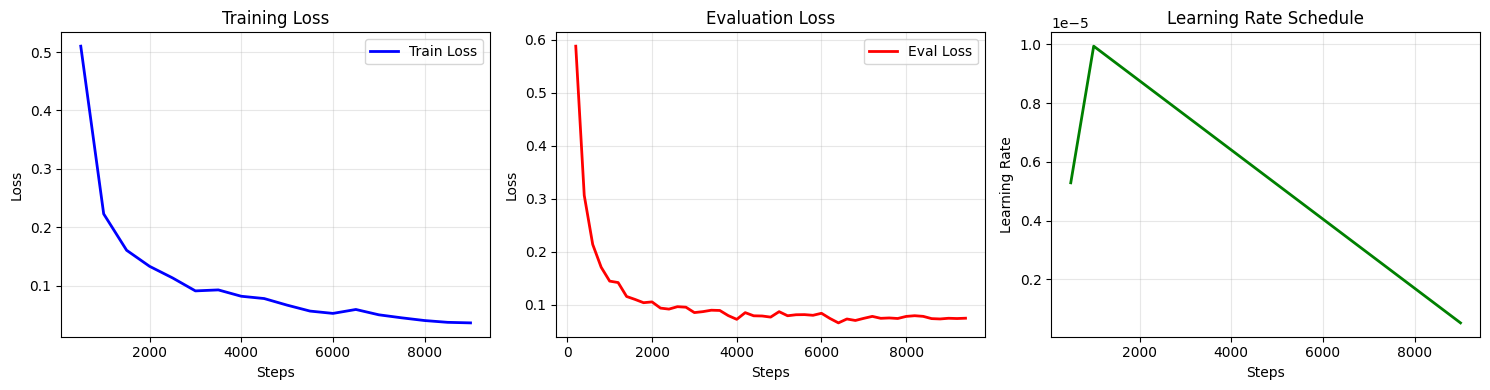

In [ ]:
plot_training_curves(full_denoise_trainer)

In [ ]:
testing = DenoiseDataset(data=Dataset.from_list(test), tokenizer=tokenizer)
predictions = predict_with_trainer(full_denoise_trainer, testing, classes=train_full_noise_dataset.tags_)
for word, label in zip(test, predictions):
      print(" ".join(word['text']) + '\n' + " ".join(label['labels']) + '\n' + " ".join(word['labels']))
      print(f"{sum([1 if i==k else 0 for i, k in zip(label['labels'], word['labels'])])}/{len(word['labels'])}")
print()

переведите деньги на мой счет
0 0 0 0 0
0 0 0 0 0
5/5
алиса какой канал переведите сто долларов на сберкнижку
0 N N N N N N N
N N N 0 0 0 0 0
2/8
выключи телевизор заблокируй карту срочно пожалуйста
0 0 0 0 0 0
N N 0 0 0 0
4/6
привет как дела что делаешь переведи пять тысяч на вклад
0 0 N N N 0 0 0 0 0
N N N N N 0 0 0 0 0
8/10
ну я ему говорю а он такой слушай переведите пожалуйста средства
0 0 0 0 N N N N 0 0 0
N N N N N N N N 0 0 0
7/11
какой баланс моей карты
0 0 0 0
0 0 0 0
4/4
погода сегодня алиса какой баланс на карте
0 0 N N N N N
N N N 0 0 0 0
1/7
переведи деньги срочно сделай тише я сказал
0 0 0 N 0 0 0
0 0 0 N N N N
4/7
перевод средств на карту сбербанка
0 0 0 0 0
0 0 0 0 0
5/5
иди сюда быстрее посмотри что я нашел переведи сто баксов
0 0 0 0 0 0 0 N N 0
N N N N N N N 0 0 0
1/10



In [ ]:
model_save_path = "full_denoise_model"
full_denoise_trainer.save_model(model_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### bctw_labels

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoModelForTokenClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer, DataCollatorForTokenClassification
# from transformers.optimization import AdamW
from torch.optim import AdamW, Adam

import numpy as np


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    pred_labels = np.argmax(logits, axis=-1)
    correct, total, seq_correct = 0, 0, 0

    tp, fp, fn = 0, 0, 0

    for i, (pred_sent_labels, sent_labels) in enumerate(zip(pred_labels, labels)):
        is_correct = True
        for pred_label, label in zip(pred_sent_labels, sent_labels):
            if label != -100:
                if pred_label == label:
                    correct += 1
                    if label == 1:
                        tp += 1
                else:
                    is_correct = False
                    if label == 1:
                        fn += 1
                    if pred_label == 1:
                        fp += 1
                total += 1
        seq_correct += int(is_correct)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {
        "Accuracy": 100 * correct / total,
        "Sentence accuracy": 100 * seq_correct / len(labels),
        "Precision": 100 * precision,
        "Recall": 100 * recall,
        "F1": 100 * f1
    }

bctw_denoise_model = AutoModelForTokenClassification.from_pretrained("FacebookAI/xlm-roberta-base", num_labels=len(train_bctw_noise_dataset.tags_))
optimizer = AdamW(bctw_denoise_model.parameters(), lr=1e-5, weight_decay=0.01)
training_args = TrainingArguments(
                  output_dir="trainer_logs", eval_strategy="steps", save_strategy='steps',
                  logging_strategy="steps", save_total_limit=2,
                  num_train_epochs=4, eval_steps=200, disable_tqdm=False,
                  metric_for_best_model='Accuracy',
                  warmup_ratio=0.1,
                  report_to="none"
              )
bctw_denoise_trainer = Trainer(
    model=bctw_denoise_model,
    optimizers=(optimizer, None),
    args=training_args,
    data_collator=DataCollatorForTokenClassification(tokenizer=tokenizer),
    train_dataset=train_bctw_noise_dataset,
    eval_dataset=test_bctw_noise_dataset,
    compute_metrics=compute_metrics)
bctw_denoise_trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,Sentence accuracy,Precision,Recall,F1
200,No log,0.291134,87.948697,37.090909,85.139747,90.406350,87.694046
400,No log,0.152704,94.033765,58.787879,94.841164,92.468294,93.639699
600,0.364198,0.121443,95.594984,67.393939,95.468696,95.246312,95.357374
800,0.364198,0.104457,96.189149,70.787879,96.155511,95.807092,95.980985
1000,0.121999,0.097960,96.664481,74.121212,96.795484,96.160814,96.477106
1200,0.121999,0.089572,96.947222,76.363636,96.741941,96.833750,96.787824
1400,0.121999,0.085775,97.188985,77.818182,97.016470,97.066690,97.041573
1600,0.087199,0.078956,97.291428,78.545455,96.942106,97.368648,97.154909
1800,0.087199,0.089512,97.188985,78.242424,97.649218,96.402381,97.021794
2000,0.060686,0.083564,97.418456,79.151515,97.127870,97.446295,97.286822


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3300, training_loss=0.11369505217581084, metrics={'train_runtime': 1393.8131, 'train_samples_per_second': 18.941, 'train_steps_per_second': 2.368, 'total_flos': 577637308383168.0, 'train_loss': 0.11369505217581084, 'epoch': 4.0})

In [ ]:
test_results = bctw_denoise_trainer.evaluate(test_bctw_noise_dataset)
test_results

{'eval_loss': 0.08723379671573639,
 'eval_Accuracy': 97.65612194722176,
 'eval_Sentence accuracy': 81.57575757575758,
 'eval_Precision': 97.42618576224498,
 'eval_Recall': 97.6447243551031,
 'eval_F1': 97.5353326439159,
 'eval_runtime': 4.839,
 'eval_samples_per_second': 340.979,
 'eval_steps_per_second': 42.777,
 'epoch': 4.0}

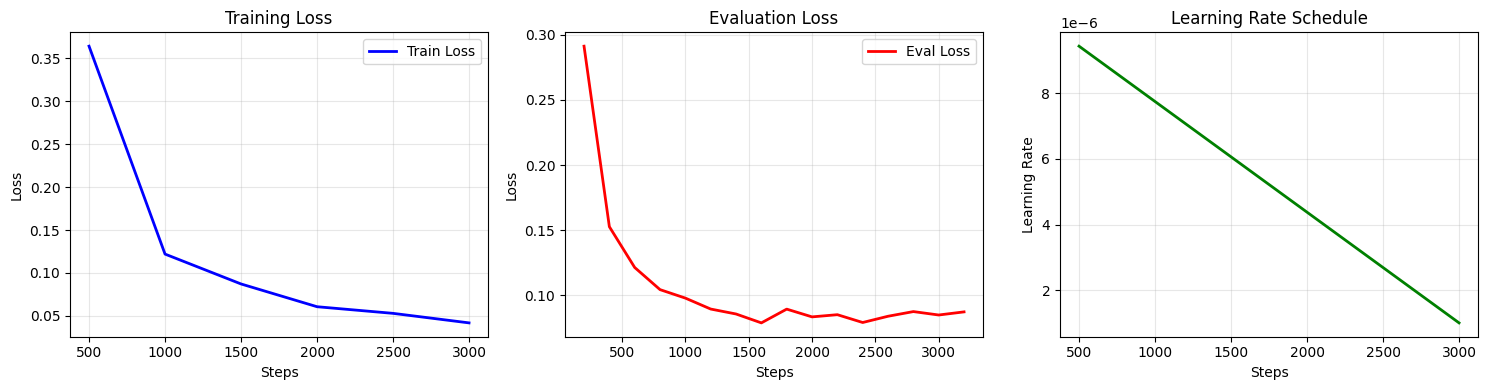

In [ ]:
plot_training_curves(bctw_denoise_trainer)

In [ ]:
testing = DenoiseDataset(data=Dataset.from_list(test), tokenizer=tokenizer)
predictions = predict_with_trainer(bctw_denoise_trainer, testing, classes=train_bctw_noise_dataset.tags_)
for word, label in zip(test, predictions):
      print(" ".join(word['text']) + '\n' + " ".join(label['labels']) + '\n' + " ".join(word['labels']))
      print(f"{sum([1 if i==k else 0 for i, k in zip(label['labels'], word['labels'])])}/{len(word['labels'])}")
print()

переведите деньги на мой счет
0 0 0 0 0
0 0 0 0 0
5/5
алиса какой канал переведите сто долларов на сберкнижку
N N N 0 0 0 0 0
N N N 0 0 0 0 0
8/8
выключи телевизор заблокируй карту срочно пожалуйста
0 0 0 0 0 0
N N 0 0 0 0
4/6
привет как дела что делаешь переведи пять тысяч на вклад
0 0 N N N 0 0 0 0 0
N N N N N 0 0 0 0 0
8/10
ну я ему говорю а он такой слушай переведите пожалуйста средства
0 0 0 0 N N N N 0 0 0
N N N N N N N N 0 0 0
7/11
какой баланс моей карты
0 0 0 0
0 0 0 0
4/4
погода сегодня алиса какой баланс на карте
0 0 N 0 0 0 0
N N N 0 0 0 0
5/7
переведи деньги срочно сделай тише я сказал
0 0 0 N N N N
0 0 0 N N N N
7/7
перевод средств на карту сбербанка
0 0 0 0 0
0 0 0 0 0
5/5
иди сюда быстрее посмотри что я нашел переведи сто баксов
0 0 0 0 0 0 0 N 0 0
N N N N N N N 0 0 0
2/10



In [ ]:
model_save_path = "bctw_denoise_model"
bctw_denoise_trainer.save_model(model_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## google-bert/bert-base-multilingual-cased

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, AutoModelForTokenClassification

google_tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-multilingual-uncased")
google_model = AutoModelForTokenClassification.from_pretrained("google-bert/bert-base-multilingual-uncased")

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/672M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: google-bert/bert-base-multilingual-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params 

### Преобразование датасетов

In [ ]:
!wget https://raw.githubusercontent.com/evagogua/denoiseML/refs/heads/main/noise_data_full.json

--2026-03-29 16:08:21--  https://raw.githubusercontent.com/evagogua/denoiseML/refs/heads/main/noise_data_full.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12014748 (11M) [text/plain]
Saving to: ‘noise_data_full.json.2’

noise_data_full.jso 100%[===================>]  11.46M  --.-KB/s    in 0.1s    

2026-03-29 16:08:21 (119 MB/s) - ‘noise_data_full.json.2’ saved [12014748/12014748]



In [ ]:
from datasets import Dataset
hf_dataset = Dataset.from_list(bctw_noise_dataset)

split_bctw_noise_dataset = hf_dataset.train_test_split(test_size=0.2, seed=42)

train_bctw_noise_dataset = DenoiseDataset(data=split_bctw_noise_dataset["train"], tokenizer=google_tokenizer)
test_bctw_noise_dataset = DenoiseDataset(data=split_bctw_noise_dataset["test"], tokenizer=google_tokenizer)

print(split_bctw_noise_dataset["train"][2])
print(train_bctw_noise_dataset[2])

{'text': ['могу', 'ли', 'я', 'изменить', 'свой', 'кредитный', 'лимит'], 'label': ['0', '0', '0', '0', '0', '0', '0'], 'oldlabel': 'credit_limit_change'}
{'input_ids': [101, 35527, 23029, 337, 10414, 88926, 15409, 316, 69900, 52762, 23029, 10550, 10386, 102], 'mask': [False, True, True, True, False, True, True, False, False, True, False, False, True, False], 'labels': array([-100,    0,    0,    0, -100,    0,    0, -100, -100,    0, -100,
       -100,    0, -100])}


In [ ]:
from datasets import Dataset
hf_dataset = Dataset.from_json('noise_data_full.json')

split_full_noise_dataset = hf_dataset.train_test_split(test_size=0.2, seed=42)


train_full_noise_dataset = DenoiseDataset(data=split_full_noise_dataset["train"], tokenizer=google_tokenizer)
test_full_noise_dataset = DenoiseDataset(data=split_full_noise_dataset["test"], tokenizer=google_tokenizer)

print(split_full_noise_dataset["train"][2])
print(train_full_noise_dataset[2])

Generating train split: 0 examples [00:00, ? examples/s]

{'text': ['вы', 'можете', 'создать', 'для', 'меня', 'почему', 'мальчикам', 'не', 'нравятса', 'девочки', 'панки', 'запрос', 'на', 'отпуск', 'исполнить', 'тогда', 'возможно', 'больше', 'не', 'захочешь', 'с', 'от', 'ее', 'значимости', 'в', 'мироощущении', 'мужчины', 'марта', 'по', 'апреля'], 'label': ['0', '0', '0', '0', '0', 'N', 'N', 'N', 'N', 'N', 'N', '0', '0', '0', 'N', 'N', 'N', 'N', 'N', 'N', '0', 'N', 'N', 'N', 'N', 'N', 'N', '0', '0', '0'], 'oldlabel': 'pto_request'}
{'input_ids': [101, 27907, 16301, 10226, 73874, 10535, 51892, 95156, 46386, 10979, 48083, 10260, 10396, 319, 51489, 13005, 12109, 88269, 81779, 12682, 26684, 10242, 33039, 19580, 10124, 10360, 54172, 37736, 18201, 46366, 24695, 35188, 25573, 10396, 10242, 37489, 13461, 76566, 323, 10360, 12586, 56026, 65028, 309, 22740, 40242, 50650, 28500, 56691, 14679, 10291, 15604, 102], 'mask': [False, True, False, True, True, True, True, True, False, False, False, True, True, False, False, False, True, False, True, False, True, 

In [ ]:
from datasets import Dataset
hf_dataset = Dataset.from_list(banking_credit_noise_dataset)

split_banking_credit_noise_dataset = hf_dataset.train_test_split(test_size=0.2, seed=42)

train_banking_credit_noise_dataset = DenoiseDataset(data=split_banking_credit_noise_dataset["train"], tokenizer=google_tokenizer)
test_banking_credit_noise_dataset = DenoiseDataset(data=split_banking_credit_noise_dataset["test"], tokenizer=google_tokenizer)

print(split_banking_credit_noise_dataset["train"][2])
print(train_banking_credit_noise_dataset[2])

{'text': ['скажи', 'мне', 'почему', 'я', 'получил', 'ошибку', 'на', 'мой', 'банковский', 'если', 'обуть', 'двадцать', 'носков', 'валенок', 'получится', 'счет'], 'label': ['0', '0', '0', '0', '0', '0', '0', '0', '0', 'N', 'N', 'N', 'N', 'N', 'N', '0'], 'oldlabel': 'account_blocked'}
{'input_ids': [101, 323, 10581, 15092, 53571, 95156, 337, 16352, 320, 13575, 85371, 10124, 55566, 46483, 34183, 18294, 12479, 42826, 12544, 93406, 11299, 14155, 10634, 12703, 31900, 10506, 82102, 14710, 22778, 40265, 102], 'mask': [False, False, False, True, True, True, True, True, False, False, True, True, True, False, True, True, False, True, False, True, False, False, True, False, False, True, False, False, True, True, False], 'labels': array([-100, -100, -100,    0,    0,    0,    0,    0, -100, -100,    0,
          0,    0, -100,    0,    1, -100,    1, -100,    1, -100, -100,
          1, -100, -100,    1, -100, -100,    1,    0, -100])}


In [ ]:
import torch

test = [
  {
    "text": "переведите деньги на мой счет".split(),
    "labels": ['0','0','0','0','0']
  },
  {
    "text": "алиса какой канал переведите сто долларов на сберкнижку".split(),
    "labels": ['N','N','N','0','0','0','0','0']
  },
  {
    "text": "выключи телевизор заблокируй карту срочно пожалуйста".split(),
    "labels": ['N','N','0','0','0','0']
  },
  {
    "text": "привет как дела что делаешь переведи пять тысяч на вклад".split(),
    "labels": ['N','N','N','N','N','0','0','0','0','0']
  },
  {
    "text": "ну я ему говорю а он такой слушай переведите пожалуйста средства".split(),
    "labels": ['N','N','N','N','N','N','N','N','0','0','0']
  },
  {
    "text": "какой баланс моей карты".split(),
    "labels": ['0','0','0','0']
  },
  {
    "text": "погода сегодня алиса какой баланс на карте".split(),
    "labels": ['N','N','N','0','0','0','0']
  },
  {
    "text": "переведи деньги срочно сделай тише я сказал".split(),
    "labels": ['0','0','0','N','N','N','N']
  },
  {
    "text": "перевод средств на карту сбербанка".split(),
    "labels": ['0','0','0','0','0']
  },
  {
    "text": "иди сюда быстрее посмотри что я нашел переведи сто баксов".split(),
    "labels": ['N','N','N','N','N', 'N', 'N', '0', '0', '0']
  }
]

### banking+credit_cards

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoModelForTokenClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer, DataCollatorForTokenClassification
# from transformers.optimization import AdamW
from torch.optim import AdamW, Adam

import numpy as np


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    pred_labels = np.argmax(logits, axis=-1)
    correct, total, seq_correct = 0, 0, 0

    tp, fp, fn = 0, 0, 0

    for i, (pred_sent_labels, sent_labels) in enumerate(zip(pred_labels, labels)):
        is_correct = True
        for pred_label, label in zip(pred_sent_labels, sent_labels):
            if label != -100:
                if pred_label == label:
                    correct += 1
                    if label == 1:
                        tp += 1
                else:
                    is_correct = False
                    if label == 1:
                        fn += 1
                    if pred_label == 1:
                        fp += 1
                total += 1
        seq_correct += int(is_correct)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {
        "Accuracy": 100 * correct / total,
        "Sentence accuracy": 100 * seq_correct / len(labels),
        "Precision": 100 * precision,
        "Recall": 100 * recall,
        "F1": 100 * f1
    }

banking_credit_denoise_google_model = AutoModelForTokenClassification.from_pretrained("google-bert/bert-base-multilingual-uncased", num_labels=len(train_banking_credit_noise_dataset.tags_))
optimizer = AdamW(banking_credit_denoise_google_model.parameters(), lr=1e-4, weight_decay=0.1)
training_args = TrainingArguments(
                  output_dir="trainer_logs", eval_strategy="steps", save_strategy='steps',
                  logging_strategy="steps", logging_steps=50, save_total_limit=2,
                  num_train_epochs=1, eval_steps=50, disable_tqdm=False,
                  metric_for_best_model='Accuracy',
                  warmup_ratio=0.1,
                  report_to="none"
              )
banking_credit_denoise_google_trainer = Trainer(
    model=banking_credit_denoise_google_model,
    optimizers=(optimizer, None),
    args=training_args,
    data_collator=DataCollatorForTokenClassification(tokenizer=google_tokenizer),
    train_dataset=train_banking_credit_noise_dataset,
    eval_dataset=test_banking_credit_noise_dataset,
    compute_metrics=compute_metrics)
banking_credit_denoise_google_trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: google-bert/bert-base-multilingual-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params 

Step,Training Loss,Validation Loss,Accuracy,Sentence accuracy,Precision,Recall,F1
50,0.456248,0.353162,85.591143,31.190476,89.947603,78.043442,83.573747
100,0.284827,0.220910,90.755239,41.547619,88.356385,92.507156,90.384141
150,0.222014,0.184458,92.937920,52.380952,92.346425,92.641859,92.493906
200,0.187917,0.165238,93.523132,53.571429,93.730782,92.389291,93.055202
250,0.184189,0.135181,94.859628,61.666667,93.487913,95.723186,94.592346
300,0.173450,0.142850,94.590747,61.547619,95.831153,92.507156,94.139822
350,0.134930,0.120252,95.436932,65.000000,95.502376,94.746590,95.122982
400,0.134425,0.111363,95.927244,68.571429,95.748988,95.571645,95.660234


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=420, training_loss=0.21787822814214797, metrics={'train_runtime': 132.662, 'train_samples_per_second': 25.328, 'train_steps_per_second': 3.166, 'total_flos': 91498775237664.0, 'train_loss': 0.21787822814214797, 'epoch': 1.0})

In [ ]:
test_results = banking_credit_denoise_google_trainer.evaluate(test_banking_credit_noise_dataset)
test_results

{'eval_loss': 0.11235994845628738,
 'eval_Accuracy': 95.86397785686042,
 'eval_Sentence accuracy': 68.57142857142857,
 'eval_Precision': 96.22738135882554,
 'eval_Recall': 94.91496884997474,
 'eval_F1': 95.56666949224379,
 'eval_runtime': 3.2378,
 'eval_samples_per_second': 259.439,
 'eval_steps_per_second': 32.43,
 'epoch': 1.0}

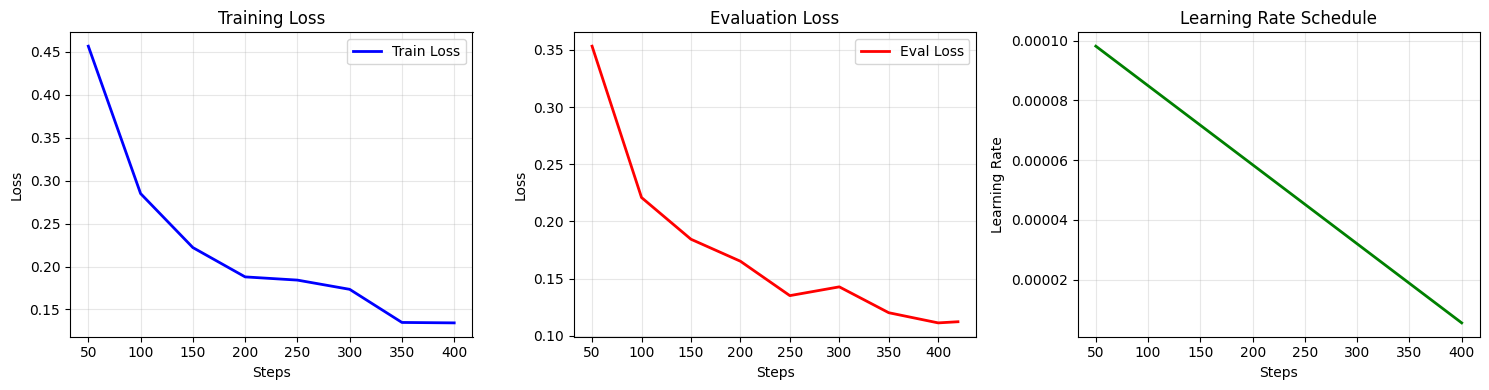

In [ ]:
plot_training_curves(banking_credit_denoise_google_trainer)

In [ ]:
testing = DenoiseDataset(data=Dataset.from_list(test), tokenizer=google_tokenizer)
predictions = predict_with_trainer(banking_credit_denoise_google_trainer, testing, classes=train_banking_credit_noise_dataset.tags_)
for word, label in zip(test, predictions):
      print(" ".join(word['text']) + '\n' + " ".join(label['labels']) + '\n' + " ".join(word['labels']))
      print(f"{sum([1 if i==k else 0 for i, k in zip(label['labels'], word['labels'])])}/{len(word['labels'])}")
print()

переведите деньги на мой счет
0 0 0 0 0
0 0 0 0 0
5/5
алиса какой канал переведите сто долларов на сберкнижку
0 0 0 0 0 0 0 0
N N N 0 0 0 0 0
5/8
выключи телевизор заблокируй карту срочно пожалуйста
0 0 0 0 N 0
N N 0 0 0 0
3/6
привет как дела что делаешь переведи пять тысяч на вклад
0 0 0 0 N 0 0 0 0 0
N N N N N 0 0 0 0 0
6/10
ну я ему говорю а он такой слушай переведите пожалуйста средства
0 N N N N N N N 0 0 0
N N N N N N N N 0 0 0
10/11
какой баланс моей карты
0 0 0 0
0 0 0 0
4/4
погода сегодня алиса какой баланс на карте
0 0 N N 0 0 0
N N N 0 0 0 0
4/7
переведи деньги срочно сделай тише я сказал
0 0 N N N N N
0 0 0 N N N N
6/7
перевод средств на карту сбербанка
0 0 0 0 0
0 0 0 0 0
5/5
иди сюда быстрее посмотри что я нашел переведи сто баксов
0 0 0 0 0 0 N 0 0 0
N N N N N N N 0 0 0
4/10



In [ ]:
model_save_path = "banking_credit_denoise_google_model"
banking_credit_denoise_google_trainer.save_model(model_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### all_labels

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoModelForTokenClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer, DataCollatorForTokenClassification
# from transformers.optimization import AdamW
from torch.optim import AdamW, Adam

import numpy as np


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    pred_labels = np.argmax(logits, axis=-1)
    correct, total, seq_correct = 0, 0, 0

    tp, fp, fn = 0, 0, 0

    for i, (pred_sent_labels, sent_labels) in enumerate(zip(pred_labels, labels)):
        is_correct = True
        for pred_label, label in zip(pred_sent_labels, sent_labels):
            if label != -100:
                if pred_label == label:
                    correct += 1
                    if label == 1:
                        tp += 1
                else:
                    is_correct = False
                    if label == 1:
                        fn += 1
                    if pred_label == 1:
                        fp += 1
                total += 1
        seq_correct += int(is_correct)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {
        "Accuracy": 100 * correct / total,
        "Sentence accuracy": 100 * seq_correct / len(labels),
        "Precision": 100 * precision,
        "Recall": 100 * recall,
        "F1": 100 * f1
    }


full_denoise_google_model = AutoModelForTokenClassification.from_pretrained("google-bert/bert-base-multilingual-uncased", num_labels=len(train_full_noise_dataset.tags_))
optimizer = AdamW(full_denoise_google_model.parameters(), lr=1e-4, weight_decay=0.1)
training_args = TrainingArguments(
                  output_dir="trainer_logs", eval_strategy="steps", save_strategy='steps',
                  logging_strategy="steps", logging_steps=50, save_total_limit=2,
                  num_train_epochs=1, eval_steps=50, disable_tqdm=False,
                  metric_for_best_model='Accuracy',
                  warmup_ratio=0.1,
                  report_to="none"
              )
full_denoise_google_trainer = Trainer(
    model=full_denoise_google_model,
    optimizers=(optimizer, None),
    args=training_args,
    data_collator=DataCollatorForTokenClassification(tokenizer=google_tokenizer),
    train_dataset=train_full_noise_dataset,
    eval_dataset=test_full_noise_dataset,
    compute_metrics=compute_metrics)
full_denoise_google_trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: google-bert/bert-base-multilingual-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params 

Step,Training Loss,Validation Loss,Accuracy,Sentence accuracy
50,0.615594,0.453111,78.165209,24.173729
100,0.424151,0.349769,84.253310,29.745763
150,0.394867,0.294042,87.511032,37.203390
200,0.323685,0.267355,88.724936,40.805085
250,0.298928,0.281112,88.337849,39.258475
300,0.278359,0.250275,89.776264,44.322034
350,0.280979,0.246123,89.718975,44.088983
400,0.260492,0.299302,88.300689,41.080508
450,0.241708,0.227487,90.784238,47.033898
500,0.262247,0.312103,87.297360,41.228814


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2360, training_loss=0.20182762241969673, metrics={'train_runtime': 1588.3629, 'train_samples_per_second': 11.886, 'train_steps_per_second': 1.486, 'total_flos': 492442317401760.0, 'train_loss': 0.20182762241969673, 'epoch': 1.0})

In [ ]:
test_results = full_denoise_google_trainer.evaluate(test_banking_credit_noise_dataset)
test_results

{'eval_loss': 0.11106012761592865,
 'eval_model_preparation_time': 0.0057,
 'eval_Accuracy': 96.01423487544484,
 'eval_Sentence accuracy': 70.35714285714286,
 'eval_Precision': 95.04392507873362,
 'eval_Recall': 96.54824044451928,
 'eval_F1': 95.790177079853,
 'eval_runtime': 4.1964,
 'eval_samples_per_second': 200.173,
 'eval_steps_per_second': 25.022}

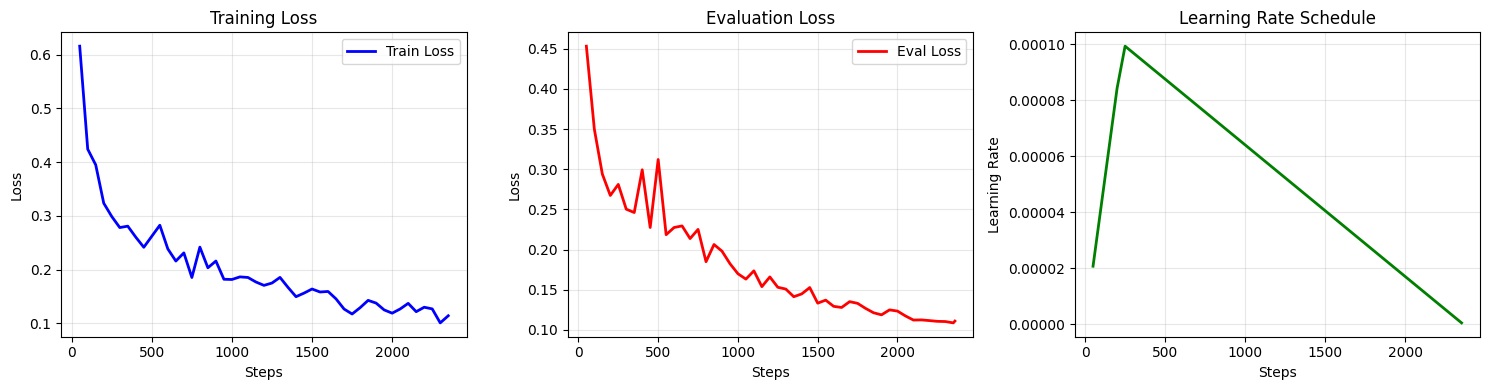

In [ ]:
plot_training_curves(full_denoise_google_trainer)

In [ ]:
testing = DenoiseDataset(data=Dataset.from_list(test), tokenizer=google_tokenizer)
predictions = predict_with_trainer(full_denoise_google_trainer, testing, classes=train_full_noise_dataset.tags_)
for word, label in zip(test, predictions):
      print(" ".join(word['text']) + '\n' + " ".join(label['labels']) + '\n' + " ".join(word['labels']))
      print(f"{sum([1 if i==k else 0 for i, k in zip(label['labels'], word['labels'])])}/{len(word['labels'])}")
print()

переведите деньги на мой счет
0 0 0 0 0
0 0 0 0 0
5/5
алиса какой канал переведите сто долларов на сберкнижку
N 0 N 0 0 0 0 0
N N N 0 0 0 0 0
7/8
выключи телевизор заблокируй карту срочно пожалуйста
0 0 0 0 N 0
N N 0 0 0 0
3/6
привет как дела что делаешь переведи пять тысяч на вклад
0 0 0 N N N N N N N
N N N N N 0 0 0 0 0
2/10
ну я ему говорю а он такой слушай переведите пожалуйста средства
N N N 0 N N N N 0 0 0
N N N N N N N N 0 0 0
10/11
какой баланс моей карты
0 0 0 0
0 0 0 0
4/4
погода сегодня алиса какой баланс на карте
0 0 N N N N N
N N N 0 0 0 0
1/7
переведи деньги срочно сделай тише я сказал
0 0 N N N 0 0
0 0 0 N N N N
4/7
перевод средств на карту сбербанка
0 0 0 0 0
0 0 0 0 0
5/5
иди сюда быстрее посмотри что я нашел переведи сто баксов
0 0 0 N 0 0 0 N 0 0
N N N N N N N 0 0 0
3/10



In [ ]:
model_save_path = "full_denoise_google_model"
full_denoise_google_trainer.save_model(model_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### bctw_labels

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoModelForTokenClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer, DataCollatorForTokenClassification
# from transformers.optimization import AdamW
from torch.optim import AdamW, Adam

import numpy as np


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    pred_labels = np.argmax(logits, axis=-1)
    correct, total, seq_correct = 0, 0, 0
    for i, (pred_sent_labels, sent_labels) in enumerate(zip(pred_labels, labels)):
        is_correct = True
        for pred_label, label in zip(pred_sent_labels, sent_labels):
            if label != -100:
                if pred_label == label:
                    correct += 1
                else:
                    is_correct = False
                total += 1
        seq_correct += int(is_correct)
    return {"Accuracy": 100 * correct / total, "Sentence accuracy": 100 * seq_correct / len(labels)}


bctw_denoise_google_model = AutoModelForTokenClassification.from_pretrained("google-bert/bert-base-multilingual-uncased", num_labels=len(train_bctw_noise_dataset.tags_))
optimizer = AdamW(bctw_denoise_google_model.parameters(), lr=1e-4, weight_decay=0.1)
training_args = TrainingArguments(
                  output_dir="trainer_logs", eval_strategy="steps", save_strategy='steps',
                  logging_strategy="steps", logging_steps=50, save_total_limit=2,
                  num_train_epochs=1, eval_steps=50, disable_tqdm=False,
                  metric_for_best_model='Accuracy',
                  warmup_ratio=0.1,
                  report_to="none"
              )
bctw_denoise_google_trainer = Trainer(
    model=bctw_denoise_google_model,
    optimizers=(optimizer, None),
    args=training_args,
    data_collator=DataCollatorForTokenClassification(tokenizer=google_tokenizer),
    train_dataset=train_bctw_noise_dataset,
    eval_dataset=test_bctw_noise_dataset,
    compute_metrics=compute_metrics)
bctw_denoise_google_trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: google-bert/bert-base-multilingual-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params 

Step,Training Loss,Validation Loss,Accuracy,Sentence accuracy
50,0.539290,0.413928,81.529569,20.545455
100,0.305873,0.413607,85.169208,33.757576
150,0.279855,0.223583,90.957447,45.454545
200,0.253000,0.196581,92.188809,49.515152
250,0.241122,0.188509,92.431731,50.303030
300,0.220873,0.185512,93.051600,53.575758
350,0.195855,0.164534,93.420171,57.030303
400,0.173208,0.149705,94.115430,59.333333
450,0.165953,0.148719,94.450494,60.909091
500,0.159857,0.130366,95.049422,64.666667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=825, training_loss=0.2038653024037679, metrics={'train_runtime': 400.8596, 'train_samples_per_second': 16.465, 'train_steps_per_second': 2.058, 'total_flos': 179735423777952.0, 'train_loss': 0.2038653024037679, 'epoch': 1.0})

In [ ]:
test_results = bctw_denoise_google_trainer.evaluate(test_bctw_noise_dataset)
test_results

{'eval_loss': 0.10240060836076736,
 'eval_model_preparation_time': 0.0055,
 'eval_Accuracy': 96.11744010722065,
 'eval_Sentence accuracy': 70.72727272727273,
 'eval_Precision': 96.3222102619304,
 'eval_Recall': 95.40648600621947,
 'eval_F1': 95.86216131768067,
 'eval_runtime': 7.0036,
 'eval_samples_per_second': 235.594,
 'eval_steps_per_second': 29.556}

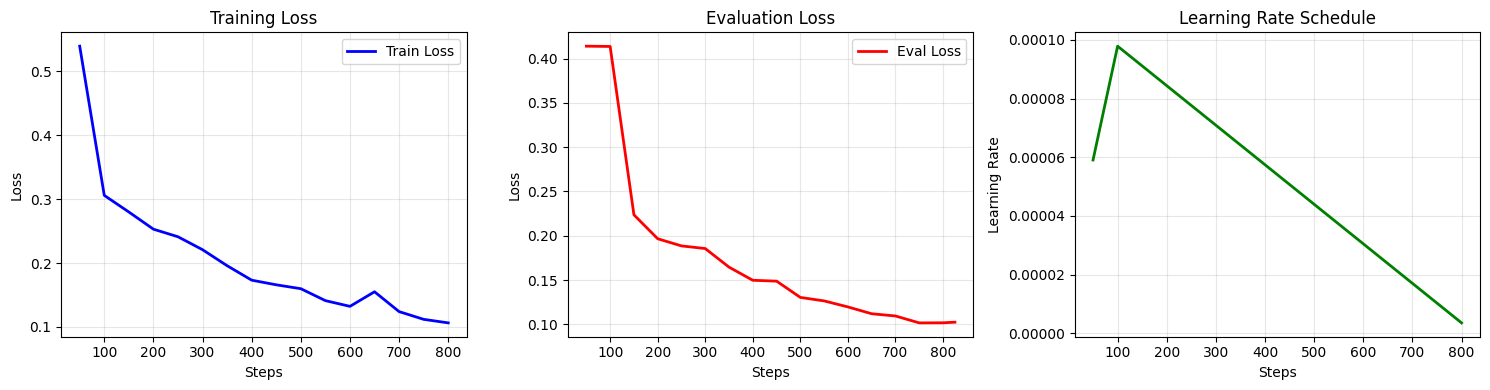

In [ ]:
plot_training_curves(bctw_denoise_google_trainer)

In [ ]:
testing = DenoiseDataset(data=Dataset.from_list(test), tokenizer=google_tokenizer)
predictions = predict_with_trainer(bctw_denoise_google_trainer, testing, classes=train_bctw_noise_dataset.tags_)
for word, label in zip(test, predictions):
      print(" ".join(word['text']) + '\n' + " ".join(label['labels']) + '\n' + " ".join(word['labels']))
      print(f"{sum([1 if i==k else 0 for i, k in zip(label['labels'], word['labels'])])}/{len(word['labels'])}")
print()

переведите деньги на мой счет
0 0 0 0 0
0 0 0 0 0
5/5
алиса какой канал переведите сто долларов на сберкнижку
0 0 0 0 0 0 0 0
N N N 0 0 0 0 0
5/8
выключи телевизор заблокируй карту срочно пожалуйста
0 N 0 0 N 0
N N 0 0 0 0
4/6
привет как дела что делаешь переведи пять тысяч на вклад
0 0 0 N N 0 0 0 0 0
N N N N N 0 0 0 0 0
7/10
ну я ему говорю а он такой слушай переведите пожалуйста средства
0 N N N N N N N 0 0 0
N N N N N N N N 0 0 0
10/11
какой баланс моей карты
0 0 0 0
0 0 0 0
4/4
погода сегодня алиса какой баланс на карте
0 0 N 0 0 0 0
N N N 0 0 0 0
5/7
переведи деньги срочно сделай тише я сказал
0 0 N N N 0 N
0 0 0 N N N N
5/7
перевод средств на карту сбербанка
0 0 0 0 0
0 0 0 0 0
5/5
иди сюда быстрее посмотри что я нашел переведи сто баксов
0 0 0 0 0 0 0 N 0 0
N N N N N N N 0 0 0
2/10



In [ ]:
model_save_path = "bctw_denoise_google_model"
bctw_denoise_google_trainer.save_model(model_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

# Классификация интентов

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, AutoModelForSequenceClassification

class_tokenizer = AutoTokenizer.from_pretrained("FacebookAI/xlm-roberta-base")

## Обучение классификационной модели на чистых данных

### Преобразование датасета

In [ ]:
from datasets import Dataset
from random import shuffle

class_dataset = Dataset.from_json('/content/ru_data.json')
new_class_data = []
for item in class_dataset:
  newdict = {}
  newtext = "".join([ch if ch.isalpha() or ch == " " else "" for ch in item['text']])
  newdict["text"] = newtext.split()
  newdict["labels"] = item['label']
  new_class_data.append(newdict)
shuffle(new_class_data)
new_class_dataset = Dataset.from_list(new_class_data)
split_class_dataset = new_class_dataset.train_test_split(test_size=0.2, seed=42)

print(f"Размер датасета: {len(class_dataset)}")
print(f"Train: {len(split_class_dataset['train'])}")
print(f"Test: {len(split_class_dataset['test'])}")
print(f"Пример: {split_class_dataset['train'][0]}")

Размер датасета: 8250
Train: 6600
Test: 1650
Пример: {'text': ['Я', 'еду', 'в', 'Бостон', 'на', 'марта', 'до', 'марта', 'пожалуйста', 'забронируйте', 'мне', 'номер', 'в', 'отеле'], 'labels': 'book_hotel'}


In [ ]:
import torch
from torch.utils.data import Dataset
from typing import List, Dict, Any, Optional

class UDDataset(Dataset):

    def __init__(self, data: List[Dict[str, Any]], tokenizer, max_length: int = 128):

        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

        self.tags_ = [
            'account_blocked',
            'application_status',
            'apr',
            'balance',
            'bill_balance',
            'bill_due',
            'book_flight',
            'book_hotel',
            'car_rental',
            'card_declined',
            'carry_on',
            'credit_limit',
            'credit_limit_change',
            'credit_score',
            'damaged_card',
            'direct_deposit',
            'exchange_rate',
            'expiration_date',
            'flight_status',
            'freeze_account',
            'improve_credit_score',
            'income',
            'insurance',
            'insurance_change',
            'interest_rate',
            'international_fees',
            'international_visa',
            'lost_luggage',
            'meeting_schedule',
            'new_card',
            'next_holiday',
            'order_checks',
            'pay_bill',
            'payday',
            'pin_change',
            'plug_type',
            'pto_balance',
            'pto_request',
            'pto_request_status',
            'pto_used',
            'redeem_rewards',
            'replacement_card_duration',
            'report_fraud',
            'report_lost_card',
            'rewards_balance',
            'schedule_meeting',
            'spending_history',
            'taxes',
            'timezone',
            'transactions',
            'transfer',
            'travel_alert',
            'travel_notification',
            'travel_suggestion',
            'vaccines'
        ]

        self.label_to_id = {label: i for i, label in enumerate(self.tags_)}
        self.id_to_label = {i: label for i, label in enumerate(self.tags_)}

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, index: int) -> Dict[str, torch.Tensor]:

        item = self.data[index]

        text = " ".join(item["text"])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            truncation=True,
            return_tensors='pt'
        )

        label_str = item["labels"]
        if label_str not in self.label_to_id:
          raise ValueError(f"Unknown label: {label_str}")
        label_id = self.label_to_id[label_str]

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label_id, dtype=torch.long)
        }

    def get_labels(self) -> List[str]:
        return self.tags_

    def get_label_mapping(self) -> Dict[str, int]:
        return self.label_to_id

SyntaxError: ':' expected after dictionary key (1260544371.py, line 107)

In [ ]:
train_class_data = UDDataset(split_class_dataset["train"], class_tokenizer)
test_class_data = UDDataset(split_class_dataset["test"], class_tokenizer)

In [ ]:
print(split_class_dataset["train"][0])
train_class_data[0]

{'text': ['Я', 'еду', 'в', 'Бостон', 'на', 'марта', 'до', 'марта', 'пожалуйста', 'забронируйте', 'мне', 'номер', 'в', 'отеле'], 'labels': 'book_hotel'}


{'input_ids': tensor([     0,   1509,      6,  91193,     49,   8159, 106318,     29,  35185,
            255,  35185, 107902,     61, 128985, 232228,   4042,  18315,     49,
            183,  28255,      2]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 'labels': tensor(7)}

### Обучение и тестирование

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoModelForTokenClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer, DataCollatorForTokenClassification
# from transformers.optimization import AdamW
from torch.optim import AdamW, Adam

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np


def compute_metrics_simple(eval_pred):

    predictions, labels = eval_pred
    predicted_labels = np.argmax(predictions, axis=-1)

    accuracy = accuracy_score(labels, predicted_labels)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predicted_labels, average='macro', zero_division=0
    )

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }


class_model = AutoModelForSequenceClassification.from_pretrained("FacebookAI/xlm-roberta-base", num_labels=len(train_class_data.tags_))
optimizer = AdamW(class_model.parameters(), lr=1e-5, weight_decay=0.01)
training_args = TrainingArguments(
                  output_dir="trainer_logs", eval_strategy="steps", save_strategy='steps',
                  logging_strategy="steps", save_total_limit=2,
                  num_train_epochs=4, eval_steps=200, disable_tqdm=False,
                  metric_for_best_model='accuracy',
                  warmup_ratio=0.1,
                  report_to="none"
              )
class_trainer = Trainer(
    model=class_model,
    optimizers=(optimizer, None),
    args=training_args,
    data_collator=DataCollatorWithPadding(tokenizer=class_tokenizer),
    train_dataset=train_class_data,
    eval_dataset=test_class_data,
    compute_metrics=compute_metrics_simple)
class_trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
200,No log,4.011796,0.019394,0.000353,0.018182,0.000692
400,No log,3.556067,0.269091,0.330881,0.280620,0.230493
600,3.881993,2.801468,0.519394,0.580644,0.523360,0.479733
800,3.881993,2.276258,0.638788,0.639500,0.648780,0.605686
1000,2.741008,1.914038,0.712121,0.766318,0.721973,0.683074
1200,2.741008,1.611752,0.766667,0.796515,0.778057,0.752296
1400,2.741008,1.371972,0.796364,0.824270,0.799070,0.778359
1600,1.875051,1.213407,0.798788,0.806380,0.808470,0.783673
1800,1.875051,1.061017,0.835152,0.853309,0.843385,0.823548
2000,1.362189,0.943338,0.862424,0.874702,0.869032,0.856580


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3300, training_loss=1.8532765151515151, metrics={'train_runtime': 882.7541, 'train_samples_per_second': 29.906, 'train_steps_per_second': 3.738, 'total_flos': 262088715289296.0, 'train_loss': 1.8532765151515151, 'epoch': 4.0})

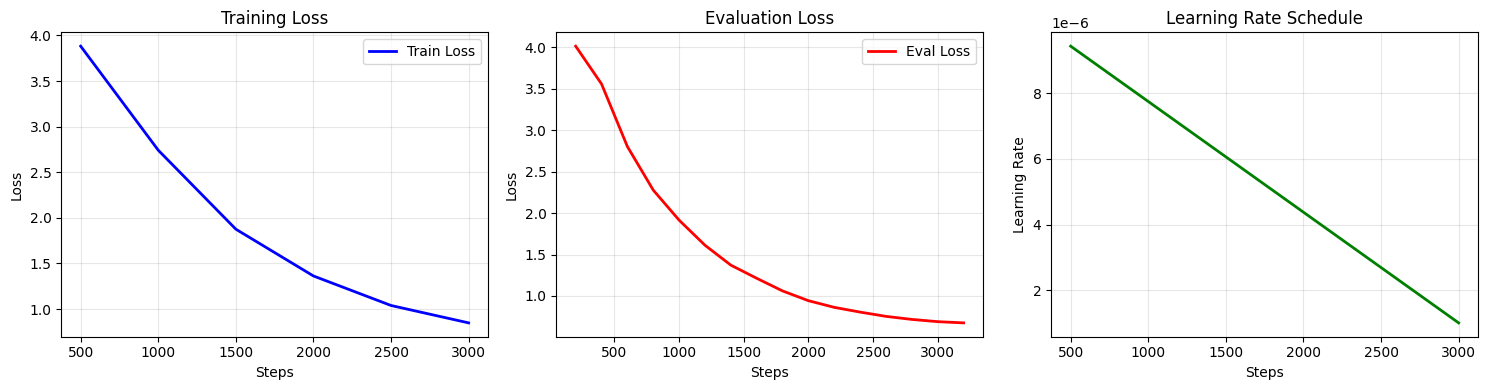

In [ ]:
plot_training_curves(class_trainer)

In [ ]:
model_save_path = "class_model"
class_trainer.save_model(model_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## Классификация шумных данных

### Преобразование шумного датасета

In [ ]:
from datasets import Dataset
hf_dataset = Dataset.from_json('/content/our_noise_data_full.json')

In [ ]:
split_dataset = hf_dataset.train_test_split(test_size=0.2, seed=42)

In [ ]:
split_dataset["test"][0]

{'text': ['почему',
  'мой',
  'кредитный',
  'счет',
  'тогда',
  'спи',
  'держится',
  'компьютерная',
  'томография',
  'на',
  'нем'],
 'label': ['0', '0', '0', '0', 'N', 'N', '0', 'N', 'N', '0', '0'],
 'oldlabel': 'account_blocked'}

In [ ]:
split_dataset_for_UD = split_dataset["test"].rename_column("oldlabel", "labels")
split_dataset_for_UD = split_dataset_for_UD.remove_columns("label")
test_data = UDDataset(split_dataset_for_UD, class_tokenizer)

In [ ]:
test_data[0]

{'input_ids': tensor([     0,  24651,  20351,  11460,   2192,  25862,  20878,  24510, 225207,
            989,  30762,   2233,   2660,  96149,     29,  21322,      2]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 'labels': tensor(0)}

### Применение классификационной модели к шумным данным

In [ ]:
import numpy as np
from scipy.special import softmax
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def predict_with_trainer_seq(trainer, dataset, classes):
    predictions = trainer.predict(dataset)
    logits = predictions.predictions

    probs = softmax(logits, axis=-1)
    pred_ids = np.argmax(probs, axis=-1)

    pred_labels = [classes[i] for i in pred_ids]
    pred_probs = np.max(probs, axis=-1)

    return pred_labels, pred_probs


def get_simple_metrics(true_labels, predicted_labels):
    accuracy = accuracy_score(true_labels, predicted_labels)
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, predicted_labels, average="macro", zero_division=0
    )

    print(f"Accuracy:  {accuracy*100}")
    print(f"Precision: {precision*100}")
    print(f"Recall:    {recall*100}")
    print(f"F1-score:  {f1*100}")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


pred_labels, pred_probs = predict_with_trainer_seq(
    class_trainer,
    test_data,
    classes=train_class_data.tags_
)

true_labels = [train_class_data.id_to_label[item["labels"].item()] for item in test_data]

metrics = get_simple_metrics(true_labels, pred_labels)

Accuracy:  80.42424242424242
Precision: 83.11199434472344
Recall:    80.73520847252028
F1-score:  80.35012426777962


## Классификация очищенных данных

### Очистка датасета denoise-моделью

In [ ]:
def cleaning(data_samples, tr, tokenizer, tag):
  biganswer = []
  test_dataset = DenoiseDataset(data_samples, tokenizer)
  predictions = predict_with_trainer(tr, test_dataset, classes=test_dataset.tags_)
  for item, probs in zip(data_samples, predictions):
    new_sample = {"text":[token for token, mask in zip(item['text'], probs['labels']) if mask == '0'], 'label': item["label"], 'oldlabel': item["oldlabel"]}
    masked = [item for item in predictions[0]["labels"] if item != -100]
    biganswer.append(new_sample)
  return biganswer

cleaned_data = cleaning(split_dataset['test'], roberta_trainer, tokenizer, ["N", "0"])

In [ ]:
df_cleaned_data = Dataset.from_list(cleaned_data)

In [ ]:
ddf_cleaned_data = Dataset.from_list(cleaned_data)
f_cleaned_data = df_cleaned_data.rename_column('oldlabel', 'labels')
split_dataset["test"] = split_dataset["test"].rename_column('oldlabel', 'labels')
# df_cleaned_data = df_cleaned_data.remove_columns('label')
# split_dataset["test"] = split_dataset["test"].remove_columns('label')

### Применение классификационной модели к очищенным данным

In [ ]:
from transformers import AutoTokenizer, DataCollatorForTokenClassification
import torch

model_path = "/content/roberta"
model = AutoModelForTokenClassification.from_pretrained(
    model_path,
    local_files_only=True,
    torch_dtype=torch.float16,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained("FacebookAI/xlm-roberta-base")
roberta_trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir="roberta_trainer",
        report_to="none"
    ),
    data_collator=DataCollatorForTokenClassification(tokenizer=tokenizer)
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:
import scipy

def predict_with_trainer(trainer, dataset, classes):
    """Простое предсказание для sequence classification"""
    predictions = trainer.predict(dataset)
    logits = predictions.predictions
    best_indices = np.argmax(logits, axis=-1)
    return [classes[i] for i in best_indices]

def get_simple_metrics(true_labels, predicted_labels):
    """
    Простая версия с основными метриками
    """
    accuracy = accuracy_score(true_labels, predicted_labels)
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, predicted_labels, average='macro', zero_division=0
    )

    print(f"Accuracy:  {accuracy*100}")
    print(f"Precision: {precision*100}")
    print(f"Recall:    {recall*100}")
    print(f"F1-score:  {f1*100}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

UDclean = UDDataset(df_cleaned_data, tokenizer=tokenizer)
predictions = predict_with_trainer(class_trainer, UDclean, classes=train_class_data.tags_)
true_labels = [train_class_data.id_to_label[item["labels"].item()] for item in UDclean]

metrics = get_simple_metrics(true_labels, predictions)

Accuracy:  91.93939393939394
Precision: 91.99716851098376
Recall:    92.06930274149771
F1-score:  91.74601970331388
